# Repairing a broken ligand network

In a relative binding free energy (RBFE) campaign some transformations may fail. If
enough edges drop out, the completed network can split into disconnected pieces,
and a disconnected network can no longer rank all of its ligands.

This notebook takes the TYK2 system from the JACS benchmark
set and repairs the network:

1. load the stored, connected **planned** network,
2. parse a directory of **result JSONs** to find which edges actually completed,
3. reconstruct the **completed** network and diff it against the plan,
4. **repair** the breaks in two different ways:
   - by ligand name
   - by lomap score
6. **rebuild** alchemical transformations for the new edges and write them out.

## 1. Fetch the data

In [1]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"  # colab hack; not needed locally

# Fetch and extract the CLI tutorial results from Zenodo
!openfe fetch rbfe-tutorial-results
!tar -xf rbfe_results.tar.gz

Fetching /Users/hannahbaumann/.local/share/mamba/envs/openfe_env/lib/python3.12/site-packages/openfecli/tests/data/rbfe_results.tar.gz


## 2. Imports

In [1]:
import json
import pathlib
import warnings

import networkx as nx
from rdkit import Chem

from openfe import (
    AlchemicalNetwork, ChemicalSystem, LigandAtomMapping, LigandNetwork,
    ProteinComponent, SmallMoleculeComponent, SolventComponent, Transformation,
)
from openfe.protocols.openmm_rfe import RelativeHybridTopologyProtocol
from openfe.setup import KartografAtomMapper, lomap_scorers
from openfe.setup.ligand_network_planning import generate_network_from_names
from gufe.tokenization import JSON_HANDLER

from konnektor.network_tools import merge_two_networks, connected_subnetworks
from konnektor.network_planners import MstConcatenator

/Users/hannahbaumann/.local/share/mamba/envs/openfe_env/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'validate_default' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'validate_default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/hannahbaumann/.local/share/mamba/envs/openfe_env/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'validate_default' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'validate_default' is field-specific metadata, and can only be attached to 

## 3. Load the planned network

This is the connected network the campaign set out to run.

In [2]:
planned = LigandNetwork.from_json("assets/mst_network_tyk2.json")

print("planned connected:", planned.is_connected(), " edges:", len(planned.edges))

planned connected: True  edges: 9


## 4. Reconstruct the completed network from the results

In a real campaign a failed transformation simply has no results. We simulate two
failures by dropping their result files before parsing:

- `ejm_31 -- ejm_46` disconnects the network into two fragments (5 and 4 ligands);
- `ejm_31 -- ejm_48` was `ejm_48`'s *only* transformation, so `ejm_48` disappears
  from the results entirely.

We then read every remaining result JSON, keep the transformations that succeeded
in both legs, and rebuild the network from their ligand mappings. We also recover a reference complex system
(for the protein, solvent and cofactors) and the run's protocol (for its
settings), both used when we rebuild transformations later.

In [3]:
def _load_result_json(path):
    """Load a result JSON, or None if it isn't a usable result."""
    ru = json.load(open(path, "rb"), cls=JSON_HANDLER.decoder)
    if not isinstance(ru, dict):
        return None  # e.g. the ligand network file
    if ru.get("__qualname__") in ("AlchemicalNetwork", "Transformation"):
        return None  # an input/alchemical network file
    if "unit_results" not in ru:
        return None
    if all("exception" in u for u in ru["unit_results"].values()):
        return None  # every repeat failed
    return ru

def _units(ru):
    data = ru["protocol_result"]["data"]
    return data[next(iter(data))]


def _extract_edge(ru):
    """Return (mapping, phase, stateA) for a result, or None if inputs are stripped."""
    units = _units(ru)
    if not units or "stateA" not in units[0]["inputs"]:
        return None
    inputs = units[0]["inputs"]
    stateA = ChemicalSystem.from_dict(inputs["stateA"])
    mapping = LigandAtomMapping.from_dict(inputs["ligandmapping"])
    is_complex = any(isinstance(c, ProteinComponent) for c in stateA.components.values())
    return mapping, ("complex" if is_complex else "solvent"), stateA

def parse_results(result_files, require_both_legs=True):
    """Reconstruct the completed network directly from the results."""
    phases = {}
    mapping_by_pair = {}
    reference_complex_system = None
    reference_protocol = None
    for path in result_files:
        ru = _load_result_json(path)
        if ru is None:
            continue
        if reference_protocol is None:
            settings = _units(ru)[0]["inputs"].get("settings")
            reference_protocol = RelativeHybridTopologyProtocol(settings=settings)
        parsed = _extract_edge(ru)
        if parsed is None:
            continue
        mapping, phase, stateA = parsed
        pair = frozenset({mapping.componentA, mapping.componentB})
        phases.setdefault(pair, set()).add(phase)
        mapping_by_pair[pair] = mapping
        if phase == "complex" and reference_complex_system is None:
            reference_complex_system = stateA

    edges = [mapping_by_pair[pair] for pair, seen in phases.items()
             if not require_both_legs or seen == {"complex", "solvent"}]
    return LigandNetwork(edges=edges), reference_complex_system, reference_protocol

In [4]:
RESULTS_DIR = pathlib.Path("results")

result_files = sorted(
    p for p in RESULTS_DIR.rglob("*.json")
    if not any(part.startswith("shared_") for part in p.parts)
)
print(f"found {len(result_files)} result files")

# Simulate two failed transformations: drop their result files (both legs) before
# parsing. Matching on ligand name in the path is robust to the filename format.
DROP_EDGES = [("ejm_31", "ejm_46"), ("ejm_31", "ejm_48")]
result_files = [
    p for p in result_files
    if not any(a in p.name and b in p.name for a, b in DROP_EDGES)
]
print(f"kept {len(result_files)} after simulating failures")

completed, reference_complex_system, reference_protocol = parse_results(result_files)
print("completed edges:", len(completed.edges), " ligands:", len(completed.nodes))
print("connected:", completed.is_connected(), "(broken, as intended)")
print("recovered protocol:", reference_protocol is not None)

found 54 result files
kept 42 after simulating failures


/Users/hannahbaumann/.local/share/mamba/envs/openfe_env/lib/python3.12/site-packages/gufe/components/smallmoleculecomponent.py:304: UserWarning: The atom hybridization data was not found and has been set to unspecified. This can be fixed by recreating the SmallMoleculeComponent from the rdkit molecule after running sanitization.
  warnings.warn(


completed edges: 7  ligands: 9
connected: False (broken, as intended)
recovered protocol: True


## 5. Inspect the damage

The two failures show up in different ways. A missing **edge** between ligands
that survive elsewhere leaves the reconstructed network *disconnected*.
`decompose` finds it with no reference needed. A missing **ligand**, whose every
transformation failed, leaves no trace in the results at all; the only way to
know it should be there is to compare against the planed network.

Here `ejm_48` is the missing ligand. We recover it from the planned network and
fold it in as its own fragment, so the repair reconnects it too.

In [6]:
def missing_ligands(planned, completed):
    """Ligands in the plan with no results at all."""
    have = {n.name for n in completed.nodes}
    return [n for n in planned.nodes if n.name not in have]


fragments = connected_subnetworks(completed)
missing = missing_ligands(planned, completed)
print("missing ligands:", [n.name for n in missing])

# fold each missing ligand in as a singleton fragment so the repair reconnects it
fragments += [LigandNetwork(nodes=[lig], edges=[]) for lig in missing]
for i, frag in enumerate(fragments):
    print(f"fragment {i}: {sorted(n.name for n in frag.nodes)}")

missing ligands: ['lig_ejm_48']
fragment 0: ['lig_ejm_46', 'lig_jmc_23', 'lig_jmc_27', 'lig_jmc_28']
fragment 1: ['lig_ejm_31', 'lig_ejm_42', 'lig_ejm_43', 'lig_ejm_47', 'lig_ejm_50']
fragment 2: ['lig_ejm_48']


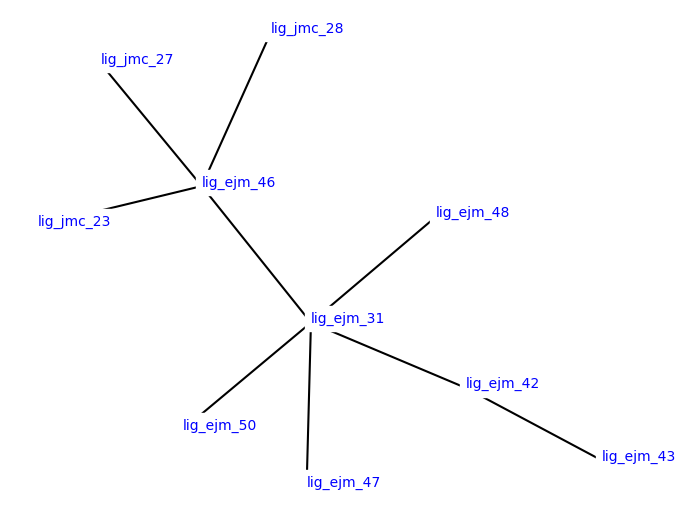

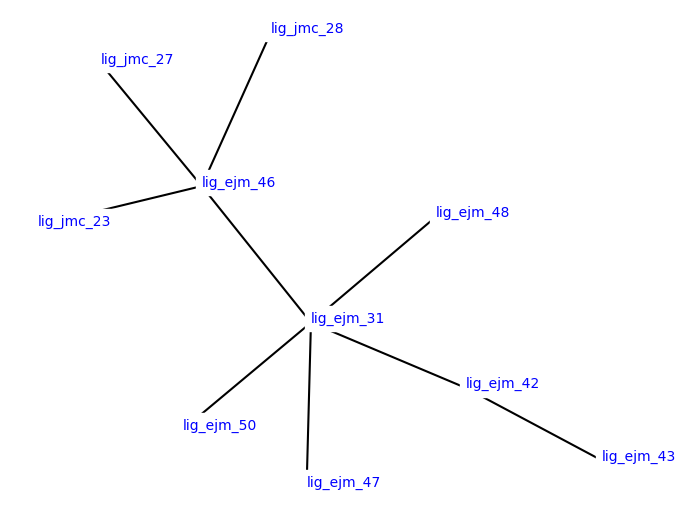

In [7]:
from openfe.utils.atommapping_network_plotting import plot_atommapping_network

plot_atommapping_network(planned)

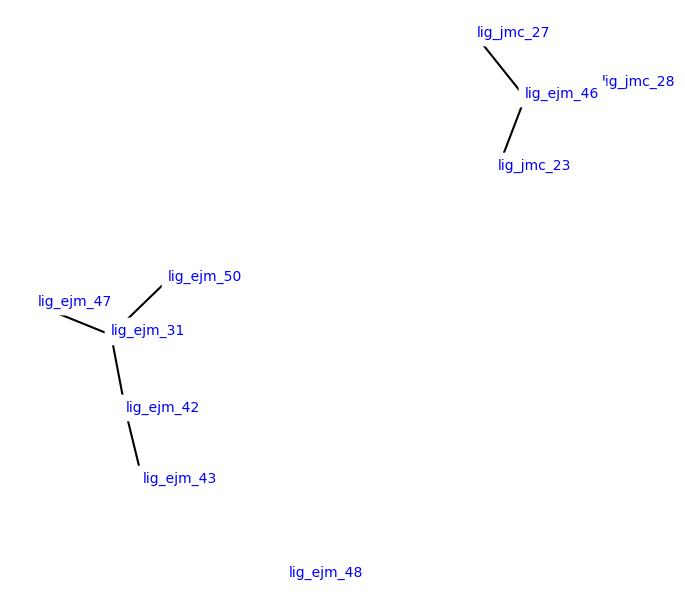

In [8]:
plot_atommapping_network(LigandNetwork(nodes=planned.nodes, edges=completed.edges))

## 6. Repair — by ligand name

When you know which ligands should bridge the gaps, name the edges explicitly.
Here we chain one representative ligand from each fragment; in practice you'd
choose these from the chemistry.

In [9]:
def repair_by_names(completed, ligands, mapper, names):
    """Reconnect a broken network with bridging edges specified by name.

    Parameters
    ----------
    completed : LigandNetwork
        The disconnected network to repair.
    ligands : list[SmallMoleculeComponent]
        The pool the named edges are drawn from. Must include any missing
        ligands that are absent from ``completed``.
    mapper : AtomMapper
        Builds the atom mapping for each new edge.
    names : list[tuple[str, str]]
        The bridging edges to add, as pairs of ligand names, e.g.
        ``[("lig_ejm_31", "lig_ejm_46"), ...]``.

    Returns
    -------
    LigandNetwork
        ``completed`` with the named bridging edges merged in.
    """
    patch = generate_network_from_names(ligands=ligands, mapper=mapper, names=names)
    return merge_two_networks(completed, patch)


reps = [sorted(frag.nodes, key=lambda n: n.name)[0].name for frag in fragments]
bridge_names = list(zip(reps[:-1], reps[1:]))
print("bridging by name:", bridge_names)

mapper = KartografAtomMapper()

# include the missing ligand(s) in the pool, since they aren't in `completed`
ligands = list(completed.nodes) + list(missing)
repaired_network_by_name = repair_by_names(completed, ligands, mapper, bridge_names)
print("connected:", repaired_network_by_name.is_connected())

bridging by name: [('lig_ejm_46', 'lig_ejm_31'), ('lig_ejm_31', 'lig_ejm_48')]
connected: True


/Users/hannahbaumann/.local/share/mamba/envs/openfe_env/lib/python3.12/site-packages/konnektor/network_planners/generators/explicit_network_generator.py:85: UserWarning: Generated network is not connected as a single network.
  warnings.warn("Generated network is not connected as a single network.")


## 7. Repair — by lomap score

Let the scorer choose the bridges: the concatenator treats each fragment as a
node and joins them with a minimum spanning tree, keeping the single best-scoring
edge per join.

The transformations that already failed are passed as `avoid_edges`, so the
concatenator never proposes them again.

In [10]:
def repair_by_score(fragments, mapper, scorer, avoid_edges=()):
    """Reconnect broken fragments with bridging edges chosen by score.

    Parameters
    ----------
    fragments : list[LigandNetwork]
        The connected subnetworks to join back together, including single-node
        networks for any missing ligands.
    mapper : AtomMapper
        Builds the atom mapping for each candidate edge.
    scorer : Callable
        Scores a mapping by expected difficulty (e.g. a lomap scorer).
    avoid_edges : Iterable[LigandAtomMapping], optional
        Edges that should not be considered when attempting to fix a network. Empty by default.

    Returns
    -------
    LigandNetwork
        A single connected network: the fragments' edges plus the chosen bridges.

    Raises
    ------
    RuntimeError
        If the fragments cannot be joined into one connected network, e.g. all
        candidate bridges between some fragments were excluded via ``avoid_edges``.
    """
    concatenator = MstConcatenator(mappers=mapper, scorer=scorer)
    return concatenator.concatenate_networks(fragments, avoid_edges=avoid_edges)

def repair_edges(repaired, completed):
    """The newly added bridges, i.e. what still needs simulating."""
    return list(set(repaired.edges) - set(completed.edges))

mapper = KartografAtomMapper()
scorer = lomap_scorers.default_lomap_score

# The planned network records every attempted transformation. Exclude them all
# so the repair never re-proposes a failed edge. 
avoid_edges = [e for e in planned.edges]

repaired_by_score = repair_by_score(fragments, mapper, scorer, avoid_edges=avoid_edges)
new_edges = repair_edges(repaired_by_score, completed)
print("edges added:", [(e.componentA.name, e.componentB.name) for e in new_edges])
print("connected:", repaired_by_score.is_connected())

edges added: [('lig_ejm_46', 'lig_ejm_47'), ('lig_ejm_46', 'lig_ejm_48')]
connected: True


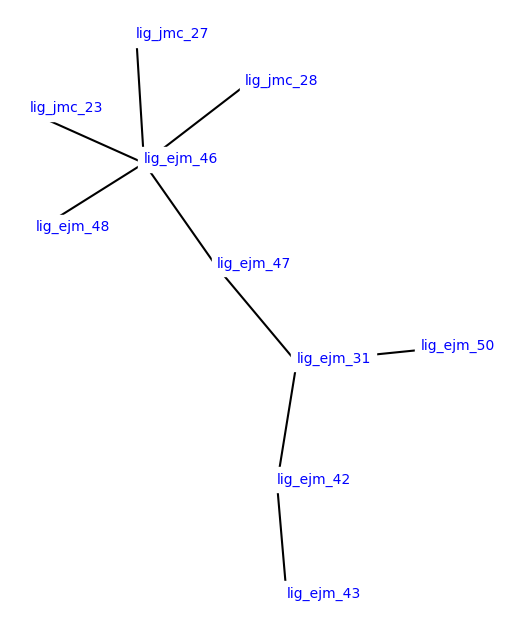

In [12]:
plot_atommapping_network(repaired_by_score)

## 8. Rebuild the alchemical transformations

Turn the new repair edges into runnable transformations — a solvent and a
complex leg each — and write them out. Protein, solvent and cofactors come from
the reference complex system, and the **protocol (with all its settings) is the
one recovered from the results**, so the repair edges match the original run.

The only exception is a charge-changing edge: the completed run may contain no
charge-changing example to copy, so we take the recovered settings and add the
explicit charge correction on top.

In [13]:
import copy


def _formal_charge_difference(mapping):
    a = Chem.rdmolops.GetFormalCharge(mapping.componentA.to_rdkit())
    b = Chem.rdmolops.GetFormalCharge(mapping.componentB.to_rdkit())
    return a - b


def _protocol_for(mapping, reference_protocol):
    """Reuse the campaign's protocol; add charge correction for charge changes."""
    if abs(_formal_charge_difference(mapping)) < 1e-3:
        return reference_protocol
    from openff.units import unit
    settings = copy.deepcopy(reference_protocol.settings)
    settings.alchemical_settings.explicit_charge_correction = True
    settings.simulation_settings.production_length = 20 * unit.nanosecond
    settings.simulation_settings.n_replicas = 22
    settings.lambda_settings.lambda_windows = 22
    return RelativeHybridTopologyProtocol(settings=settings)


def _components_from_reference(reference_complex_system):
    protein = next(c for c in reference_complex_system.components.values()
                   if isinstance(c, ProteinComponent))
    solvent = next((c for c in reference_complex_system.components.values()
                    if isinstance(c, SolventComponent)), SolventComponent())
    cofactors = {name: comp
                 for name, comp in reference_complex_system.components.items()
                 if name.startswith("cofactor")}
    return protein, solvent, cofactors


def build_alchemical_network(repair_network, reference_complex_system, reference_protocol):
    protein, solvent, cofactors = _components_from_reference(reference_complex_system)
    transformations = []
    for mapping in repair_network.edges:
        protocol = _protocol_for(mapping, reference_protocol)
        if protocol is not reference_protocol:
            warnings.warn(
                f"charge-changing edge {mapping.componentA.name} -> "
                f"{mapping.componentB.name}; added explicit charge correction"
            )
        for leg in ("solvent", "complex"):
            sysA = {"ligand": mapping.componentA, "solvent": solvent}
            sysB = {"ligand": mapping.componentB, "solvent": solvent}
            if leg == "complex":
                sysA["protein"] = sysB["protein"] = protein
                sysA.update(cofactors)
                sysB.update(cofactors)
            transformations.append(Transformation(
                stateA=ChemicalSystem(sysA),
                stateB=ChemicalSystem(sysB),
                mapping=mapping,
                protocol=protocol,
                name=f"{leg}_{mapping.componentA.name}_{mapping.componentB.name}",
            ))
    return AlchemicalNetwork(transformations)


def save_transformations(network, out_dir):
    out_dir = pathlib.Path(out_dir)
    (out_dir / "transformations").mkdir(parents=True, exist_ok=True)
    with open(out_dir / "alchemical_network.json", "w") as f:
        json.dump(network.to_dict(), f, cls=JSON_HANDLER.encoder)
    for transform in network.edges:
        transform.to_json(out_dir / "transformations" / f"{transform.name}.json")

In [14]:
# use the repair produced by the score-based strategy
repair_network = LigandNetwork(edges=new_edges)

alchemical_network = build_alchemical_network(
    repair_network, reference_complex_system, reference_protocol
)
save_transformations(alchemical_network, "repair_transformations")
print("wrote", len(alchemical_network.edges), "transformations")

wrote 4 transformations
